In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('Salary_dataset.csv')
X = df[['YearsExperience']]
y = df['Salary']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = model.predict(X_test)
print(f"Slope: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")

Slope: 9423.82
Intercept: 24380.20
R-squared: 0.9024


analysis and generate the visualizations

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
print("--- Descriptive Statistics ---")
stats = df[['YearsExperience', 'Salary']].describe()
print(stats)

--- Descriptive Statistics ---
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.413333   76004.000000
std           2.837888   27414.429785
min           1.200000   37732.000000
25%           3.300000   56721.750000
50%           4.800000   65238.000000
75%           7.800000  100545.750000
max          10.600000  122392.000000


In [8]:
print("\n--- Correlation ---")
correlation = df['YearsExperience'].corr(df['Salary'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")


--- Correlation ---
Pearson Correlation Coefficient: 0.9782


In [9]:
sns.set_theme(style="whitegrid")

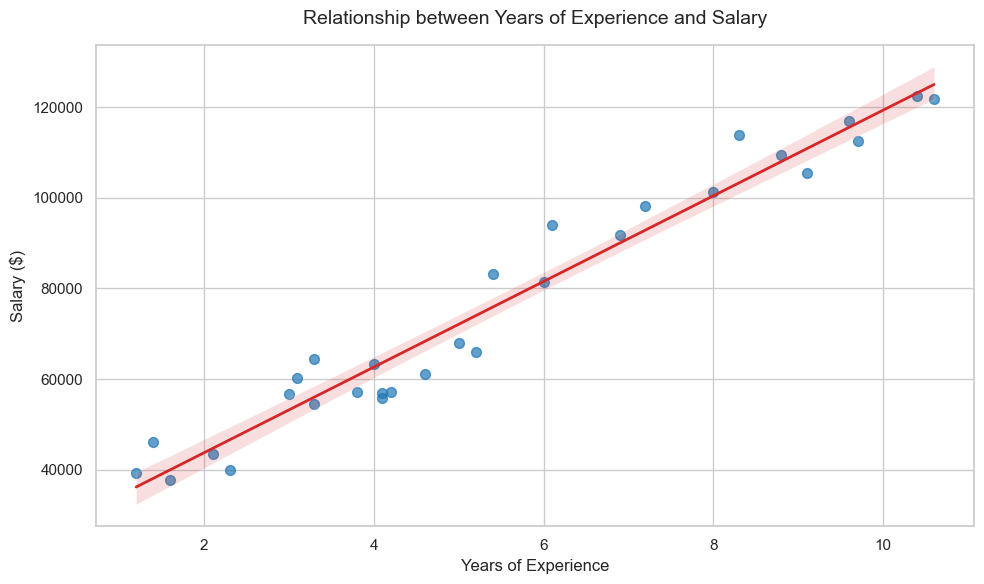

In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(
    x='YearsExperience', 
    y='Salary', 
    data=df, 
    scatter_kws={'s': 50, 'alpha': 0.7, 'color': '#1f77b4'}, 
    line_kws={'color': '#d62728', 'lw': 2}
)
plt.title('Relationship between Years of Experience and Salary', fontsize=14, pad=15)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.tight_layout()
plt.savefig('relationship_plot.png', dpi=300)
plt.show()

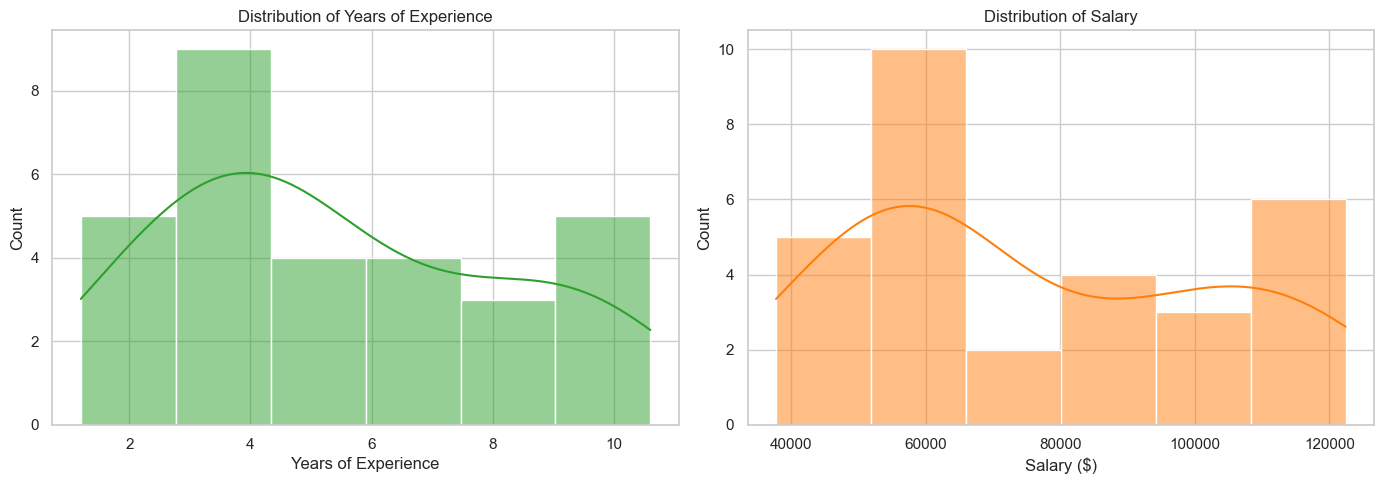

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experience Distribution
sns.histplot(df['YearsExperience'], kde=True, ax=axes[0], color='#2ca02c')
axes[0].set_title('Distribution of Years of Experience', fontsize=12)
axes[0].set_xlabel('Years of Experience')

# Salary Distribution
sns.histplot(df['Salary'], kde=True, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Distribution of Salary', fontsize=12)
axes[1].set_xlabel('Salary ($)')

plt.tight_layout()
plt.savefig('distribution_plot.png', dpi=300)
plt.show()

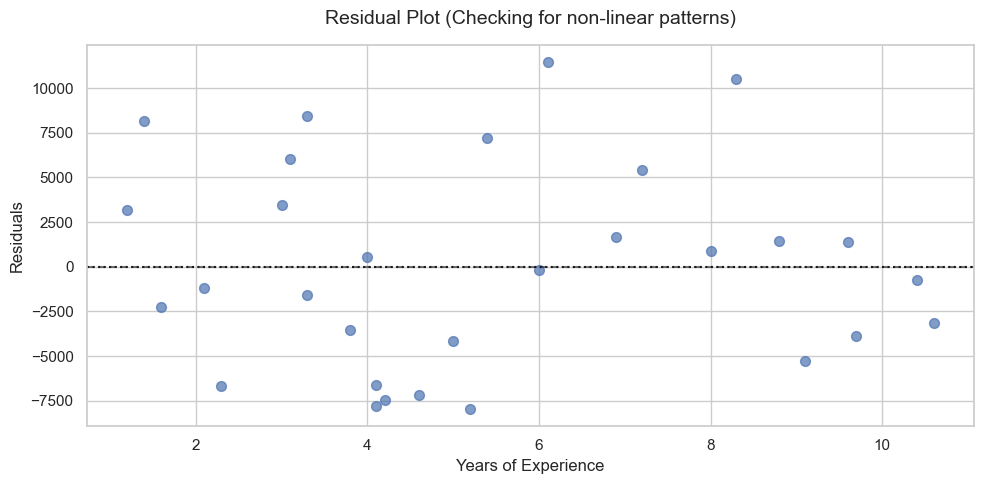

In [ ]:
plt.figure(figsize=(10, 5))
sns.residplot(
    x='YearsExperience', 
    y='Salary', 
    data=df, 
    scatter_kws={'s': 50, 'alpha': 0.7} 
)
plt.title('Residual Plot (Checking for non-linear patterns)', fontsize=14, pad=15)
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300)
plt.show()